# 🔀 Ensamble híbrido NER — spaCy + Stanza + BETO

## Arquitectura del ensamble

El ensamble combina tres modelos con perfiles complementarios,
asignando cada categoría de entidad al modelo que mejor la detecta:

```
Texto de entrada
       │
       ├──► spaCy es_core_news_lg   (rápido, alta precisión LOC)
       ├──► Stanza-ES               (mejor PER y ORG)
       └──► BETO-NER                (mejor MISC)
                  │
                  ▼
         Fusión por reglas de categoría
                  │
         ┌────────┼────────┬─────────┐
         ▼        ▼        ▼         ▼
        PER      ORG      LOC       MISC
       Stanza  Stanza   spaCy∩Stanza BETO
               +boost    o spaCy
               spaCy
                  │
                  ▼
         Resolución de conflictos
         (span más largo, coincidencia múltiple)
                  │
                  ▼
         Lista final de entidades + confianza
```

## Reglas de categoría

| Categoría | Regla | Confianza |
|---|---|---|
| **PER** | Usar Stanza directamente | HIGH |
| **MISC** | Usar BETO directamente | MEDIUM |
| **ORG** | Stanza como base; si spaCy también detecta → subir confianza | MEDIUM → HIGH |
| **LOC** | Si Stanza y spaCy coinciden → aceptar; si no → usar spaCy | HIGH / MEDIUM |

## Resolución de conflictos de span

Cuando dos entidades se solapan en el mismo rango de caracteres:
1. Ganar la que tiene **más votos** (más modelos la detectaron)
2. En empate, ganar la de **span más largo**
3. En empate, respetar el **orden de prioridad de categoría**: PER > ORG > LOC > MISC


## 0. Instalación

In [ ]:
!pip install -q stanza spacy transformers torch datasets pandas numpy matplotlib seaborn tabulate
!python -m spacy download es_core_news_lg -q
print("✅ OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 28.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 3.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ OK


## 1. Imports y métricas

In [ ]:
import warnings, time, re, json, urllib.request
from collections import defaultdict, Counter
warnings.filterwarnings("ignore")

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", 60)

HAS_GPU = torch.cuda.is_available()
print(f"GPU: {HAS_GPU}" + (f" — {torch.cuda.get_device_name(0)}" if HAS_GPU else ""))

# ── Normalización de etiquetas ────────────────────────────────
LABEL_MAP = {
    "PER":"PER","PERSON":"PER","B-PER":"PER","I-PER":"PER",
    "ORG":"ORG","NORP":"ORG","B-ORG":"ORG","I-ORG":"ORG",
    "LOC":"LOC","GPE":"LOC","FAC":"LOC","B-LOC":"LOC","I-LOC":"LOC",
    "MISC":"MISC","PRODUCT":"MISC","EVENT":"MISC","B-MISC":"MISC","I-MISC":"MISC",
}
def norm(l): return LABEL_MAP.get(l.upper().strip(), "MISC")

# ── Métricas ──────────────────────────────────────────────────
def exact_metrics(gold, pred):
    g={(s,e,norm(l)) for s,e,l,*_ in gold}
    p={(s,e,norm(l)) for s,e,l,*_ in pred}
    tp=len(g&p); fp=len(p-g); fn=len(g-p)
    P=tp/(tp+fp) if tp+fp else 0.
    R=tp/(tp+fn) if tp+fn else 0.
    return {"tp":tp,"fp":fp,"fn":fn,"P":P,"R":R,"F1":2*P*R/(P+R) if P+R else 0.}

def partial_metrics(gold, pred, min_j=0.5):
    matched=set(); tp=fp=0
    for ps,pe,pl,*_ in pred:
        pl_n=norm(pl); bj=0; bi=None
        for i,(gs,ge,gl,*_) in enumerate(gold):
            if norm(gl)!=pl_n or i in matched: continue
            inter=max(0,min(pe,ge)-max(ps,gs)); union=max(pe,ge)-min(ps,gs)
            j=inter/union if union else 0
            if j>bj: bj,bi=j,i
        if bj>=min_j and bi is not None: tp+=1; matched.add(bi)
        else: fp+=1
    fn=len(gold)-len(matched)
    P=tp/(tp+fp) if tp+fp else 0.; R=tp/(tp+fn) if tp+fn else 0.
    return {"tp":tp,"fp":fp,"fn":fn,"P":P,"R":R,"F1":2*P*R/(P+R) if P+R else 0.}

def aggregate(results):
    tp=sum(r["tp"] for r in results); fp=sum(r["fp"] for r in results)
    fn=sum(r["fn"] for r in results)
    P=tp/(tp+fp) if tp+fp else 0.; R=tp/(tp+fn) if tp+fn else 0.
    return {"tp":tp,"fp":fp,"fn":fn,"P":P,"R":R,"F1":2*P*R/(P+R) if P+R else 0.}

def cat_metrics(corpus, pred_fn):
    cat_r=defaultdict(list)
    for s in corpus:
        preds=pred_fn(s)
        for cat in ["PER","ORG","LOC","MISC"]:
            g=[(a,b,c) for a,b,c,*_ in s["entities"] if norm(c)==cat]
            p=[(a,b,c) for a,b,c,*_ in preds if norm(c)==cat]
            cat_r[cat].append(exact_metrics(g,p))
    return {c:aggregate(v) for c,v in cat_r.items()}

print("✅ Setup OK")


GPU: False
✅ Setup OK


## 2. Carga de los tres modelos

In [ ]:
import stanza, spacy
from transformers import pipeline as hf_pipeline

# ── spaCy ────────────────────────────────────────────────────
print("⏳ Cargando spaCy es_core_news_lg...")
spacy.require_cpu()
NLP_SPACY = spacy.load("es_core_news_lg")

def predict_spacy(text):
    doc = NLP_SPACY(text)
    return [(e.start_char, e.end_char, norm(e.label_), e.text)
            for e in doc.ents]

# ── Stanza ───────────────────────────────────────────────────
print("⏳ Cargando Stanza-ES...")
stanza.download("es", verbose=False)
NLP_STANZA = stanza.Pipeline("es", processors="tokenize,ner",
                              verbose=False, use_gpu=False)

def predict_stanza(text):
    doc = NLP_STANZA(text)
    return [(e.start_char, e.end_char, norm(e.type), e.text)
            for sent in doc.sentences for e in sent.ents]

# ── BETO-NER ─────────────────────────────────────────────────
print("⏳ Cargando BETO-NER...")
_DEVICE = 0 if HAS_GPU else -1
NLP_BETO = hf_pipeline(
    "ner",
    model="mrm8488/bert-spanish-cased-finetuned-ner",
    tokenizer=("mrm8488/bert-spanish-cased-finetuned-ner", {"use_fast": False}),
    aggregation_strategy="simple",
    device=_DEVICE,
)

def predict_beto(text):
    try:
        return [(e["start"], e["end"], norm(e["entity_group"]), e["word"])
                for e in NLP_BETO(text)]
    except Exception:
        return []

print("✅ Los tres modelos listos")


⏳ Cargando spaCy es_core_news_lg...
⏳ Cargando Stanza-ES...
⏳ Cargando BETO-NER...


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: mrm8488/bert-spanish-cased-finetuned-ner
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Los tres modelos listos


## 3. Motor del ensamble híbrido

El ensamble se implementa en tres fases:

### Fase 1 — Recopilación de candidatos por categoría

Cada modelo aporta sus predicciones. Las etiquetamos con el modelo de origen
y las agrupamos por categoría.

### Fase 2 — Selección por regla de categoría

```
PER  → candidatos de Stanza
MISC → candidatos de BETO
ORG  → candidatos de Stanza
         si spaCy también detecta un ORG solapado → confianza HIGH
         si solo Stanza → confianza MEDIUM
LOC  → si Stanza y spaCy coinciden (solapamiento ≥ 50%) → HIGH
        si solo spaCy → MEDIUM
        si solo Stanza → LOW (descartado por defecto, spaCy es mejor en LOC)
```

### Fase 3 — Resolución de conflictos de span

Cuando dos entidades seleccionadas se solapan:
1. Gana la que tiene más votos de modelos distintos
2. En empate → span más largo
3. En empate → prioridad PER > ORG > LOC > MISC


In [ ]:
# ════════════════════════════════════════════════════════════════
# CONSTANTES
# ════════════════════════════════════════════════════════════════

CAT_PRIORITY = {"PER": 4, "ORG": 3, "LOC": 2, "MISC": 1}

CONFIDENCE_LABEL = {
    3: "HIGH",    # 3 modelos coinciden
    2: "HIGH",    # 2 modelos coinciden
    1: "MEDIUM",  # 1 solo modelo, regla primaria
    0: "LOW",     # no debería aparecer en salida
}

# ════════════════════════════════════════════════════════════════
# FASE 1 — Obtener predicciones de los tres modelos
# ════════════════════════════════════════════════════════════════

def get_all_predictions(text):
    """
    Ejecuta los tres modelos y devuelve sus predicciones etiquetadas.
    Retorna dict: {modelo: [(start, end, cat, span), ...]}
    """
    return {
        "spacy":  predict_spacy(text),
        "stanza": predict_stanza(text),
        "beto":   predict_beto(text),
    }

# ════════════════════════════════════════════════════════════════
# UTILIDAD — Solapamiento entre spans
# ════════════════════════════════════════════════════════════════

def overlap_ratio(s1, e1, s2, e2):
    """Jaccard entre dos spans de caracteres."""
    inter = max(0, min(e1, e2) - max(s1, s2))
    union = max(e1, e2) - min(s1, s2)
    return inter / union if union > 0 else 0.0

def has_overlap(s1, e1, s2, e2, min_j=0.5):
    return overlap_ratio(s1, e1, s2, e2) >= min_j

# ════════════════════════════════════════════════════════════════
# FASE 2 — Selección por regla de categoría
# ════════════════════════════════════════════════════════════════

def select_candidates(preds):
    """
    Aplica las reglas de categoría y devuelve candidatos con votos y confianza.
    Retorna lista de dicts:
      {start, end, cat, span, votos, confianza, modelos}
    """
    spacy_p  = preds["spacy"]
    stanza_p = preds["stanza"]
    beto_p   = preds["beto"]

    candidates = []

    # ── PER: usar Stanza ─────────────────────────────────────
    for s, e, cat, span in stanza_p:
        if cat != "PER":
            continue
        # contar votos: ¿los otros modelos también detectan este PER?
        modelos = ["stanza"]
        votos = 1
        for ps, pe, pc, _ in spacy_p:
            if pc == "PER" and has_overlap(s, e, ps, pe):
                votos += 1; modelos.append("spacy"); break
        for pb, pe2, pc2, _ in beto_p:
            if pc2 == "PER" and has_overlap(s, e, pb, pe2):
                votos += 1; modelos.append("beto"); break
        candidates.append({
            "start": s, "end": e, "cat": "PER", "span": span,
            "votos": votos, "confianza": CONFIDENCE_LABEL[votos],
            "modelos": modelos, "regla": "PER→Stanza",
        })

    # ── MISC: usar BETO ──────────────────────────────────────
    for s, e, cat, span in beto_p:
        if cat != "MISC":
            continue
        modelos = ["beto"]
        votos = 1
        for ps, pe, pc, _ in stanza_p:
            if pc == "MISC" and has_overlap(s, e, ps, pe):
                votos += 1; modelos.append("stanza"); break
        for ps, pe, pc, _ in spacy_p:
            if pc == "MISC" and has_overlap(s, e, ps, pe):
                votos += 1; modelos.append("spacy"); break
        candidates.append({
            "start": s, "end": e, "cat": "MISC", "span": span,
            "votos": votos, "confianza": CONFIDENCE_LABEL[votos],
            "modelos": modelos, "regla": "MISC→BETO",
        })

    # ── ORG: Stanza base + boost si spaCy coincide ───────────
    for s, e, cat, span in stanza_p:
        if cat != "ORG":
            continue
        modelos = ["stanza"]
        votos = 1
        spacy_agrees = False
        for ps, pe, pc, _ in spacy_p:
            if pc == "ORG" and has_overlap(s, e, ps, pe):
                votos += 1; modelos.append("spacy")
                spacy_agrees = True; break
        for pb, pe2, pc2, _ in beto_p:
            if pc2 == "ORG" and has_overlap(s, e, pb, pe2):
                votos += 1; modelos.append("beto"); break
        conf = "HIGH" if spacy_agrees else "MEDIUM"
        candidates.append({
            "start": s, "end": e, "cat": "ORG", "span": span,
            "votos": votos, "confianza": conf,
            "modelos": modelos,
            "regla": "ORG→Stanza+boost" if spacy_agrees else "ORG→Stanza",
        })

    # ── LOC: Stanza ∩ spaCy → HIGH; solo spaCy → MEDIUM ─────
    # Primero: coincidencias Stanza + spaCy
    stanza_locs = [(s,e,sp) for s,e,cat,sp in stanza_p if cat=="LOC"]
    spacy_locs  = [(s,e,sp) for s,e,cat,sp in spacy_p  if cat=="LOC"]
    matched_stanza = set()
    matched_spacy  = set()

    for i,(ss,se,ssp) in enumerate(stanza_locs):
        for j,(ps,pe,psp) in enumerate(spacy_locs):
            if j in matched_spacy: continue
            if has_overlap(ss,se,ps,pe):
                # Span más largo de los dos
                if (se-ss) >= (pe-ps):
                    span_f, sf, ef = ssp, ss, se
                else:
                    span_f, sf, ef = psp, ps, pe
                modelos = ["stanza","spacy"]
                votos = 2
                for pb,pe2,pc2,_ in beto_p:
                    if pc2=="LOC" and has_overlap(sf,ef,pb,pe2):
                        votos+=1; modelos.append("beto"); break
                candidates.append({
                    "start": sf, "end": ef, "cat": "LOC", "span": span_f,
                    "votos": votos, "confianza": "HIGH",
                    "modelos": modelos, "regla": "LOC→Stanza∩spaCy",
                })
                matched_stanza.add(i); matched_spacy.add(j); break

    # Solo spaCy → MEDIUM (spaCy mejor en LOC abierto)
    for j,(ps,pe,psp) in enumerate(spacy_locs):
        if j in matched_spacy:
            continue
        modelos = ["spacy"]
        votos = 1
        for pb,pe2,pc2,_ in beto_p:
            if pc2=="LOC" and has_overlap(ps,pe,pb,pe2):
                votos+=1; modelos.append("beto"); break
        candidates.append({
            "start": ps, "end": pe, "cat": "LOC", "span": psp,
            "votos": votos, "confianza": "MEDIUM",
            "modelos": modelos, "regla": "LOC→soloSpaCy",
        })

    # Solo Stanza en LOC (sin spaCy) → descartar (baja confianza)
    # (No se añaden a candidates)

    return candidates

# ════════════════════════════════════════════════════════════════
# FASE 3 — Resolución de conflictos de span
# ════════════════════════════════════════════════════════════════

def resolve_conflicts(candidates):
    """
    Elimina solapamientos entre candidatos.
    Criterios (en orden):
      1. Más votos gana
      2. Span más largo gana
      3. Prioridad de categoría: PER > ORG > LOC > MISC
    """
    # Ordenar por criterios inversos (el último sort es el más importante)
    sorted_cands = sorted(
        candidates,
        key=lambda x: (
            x["votos"],
            x["end"] - x["start"],
            CAT_PRIORITY.get(x["cat"], 0),
        ),
        reverse=True,
    )

    accepted = []
    for cand in sorted_cands:
        cs, ce = cand["start"], cand["end"]
        # Comprobar si solapa con algún candidato ya aceptado
        conflict = any(
            has_overlap(cs, ce, a["start"], a["end"], min_j=0.01)
            for a in accepted
        )
        if not conflict:
            accepted.append(cand)

    return sorted(accepted, key=lambda x: x["start"])

# ════════════════════════════════════════════════════════════════
# FUNCIÓN PRINCIPAL DE ENSAMBLE
# ════════════════════════════════════════════════════════════════

def predict_ensemble(sample):
    """
    Ejecuta el ensamble híbrido sobre un sample.
    Devuelve lista de (start, end, cat, span) compatible con exact_metrics.
    """
    text = sample["text"] if isinstance(sample, dict) else sample
    preds = get_all_predictions(text)
    candidates = select_candidates(preds)
    final = resolve_conflicts(candidates)
    return [(c["start"], c["end"], c["cat"], c["span"]) for c in final]

def predict_ensemble_full(text):
    """
    Igual que predict_ensemble pero devuelve los dicts completos
    con confianza, votos y regla aplicada (para análisis e interfaz).
    """
    preds = get_all_predictions(text)
    candidates = select_candidates(preds)
    return resolve_conflicts(candidates)

print("✅ Motor del ensamble definido")
print()
# Test rápido
_test = "El presidente Pedro Sánchez se reunió con Angela Merkel en Berlín."
_res = predict_ensemble_full(_test)
print(f"Test: '{_test}'")
for r in _res:
    print(f"  [{r['cat']:4s}][{r['confianza']:6s}][votos={r['votos']}]"
          f"[{','.join(r['modelos'])}] '{r['span']}' — regla: {r['regla']}")


✅ Motor del ensamble definido

Test: 'El presidente Pedro Sánchez se reunió con Angela Merkel en Berlín.'
  [PER ][HIGH  ][votos=3][stanza,spacy,beto] 'Pedro Sánchez' — regla: PER→Stanza
  [PER ][HIGH  ][votos=3][stanza,spacy,beto] 'Angela Merkel' — regla: PER→Stanza
  [LOC ][HIGH  ][votos=3][stanza,spacy,beto] 'Berlín' — regla: LOC→Stanza∩spaCy


## 4. Carga del corpus de evaluación — CoNLL-2002 ES testb

In [ ]:
from datasets import load_dataset

def iob_to_corpus(words_list, labels_list):
    samples = []
    for words, labels in zip(words_list, labels_list):
        text = " ".join(words)
        char_starts=[]; cur=0
        for w in words: char_starts.append(cur); cur+=len(w)+1
        entities=[]; i=0
        while i<len(labels):
            lbl=labels[i]
            if lbl.startswith("B-") or lbl.startswith("S-"):
                etype=lbl[2:]; start=char_starts[i]; j=i+1
                while j<len(labels) and (labels[j].startswith("I-") or
                                          labels[j].startswith("E-")): j+=1
                end=char_starts[j-1]+len(words[j-1])
                span=text[start:end]
                if span.strip(): entities.append((start,end,etype,span))
                i=j
            else: i+=1
        if entities: samples.append({"text":text,"entities":entities})
    return samples

# ── CoNLL-2002 testb ─────────────────────────────────────────
print("⬇️  CoNLL-2002 ES testb...")
URL = ("https://raw.githubusercontent.com/teropa/nlp/master"
       "/resources/corpora/conll2002/esp.testb")
urllib.request.urlretrieve(URL, "esp_testb.txt")

sentences, words, labels = [], [], []
with open("esp_testb.txt", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line=line.strip()
        if not line or line.startswith("-DOCSTART-"):
            if words:
                sentences.append((list(words),list(labels)))
                words.clear(); labels.clear()
        else:
            parts=line.split(); words.append(parts[0]); labels.append(parts[-1])
if words: sentences.append((words,labels))

w_list, l_list = zip(*sentences)
CORPUS = iob_to_corpus(list(w_list), list(l_list))
dist = Counter(norm(l) for s in CORPUS for _,_,l,*_ in s["entities"])
print(f"  ✅ CoNLL-2002 testb: {len(CORPUS)} frases | "
      f"{sum(len(s['entities']) for s in CORPUS)} ents | {dict(dist)}")

# ── WikiANN-ES (dominio diferente, benchmark adicional) ───────
print("⬇️  WikiANN-ES...")
WANN = ["O","B-PER","I-PER","B-ORG","I-ORG","B-LOC","I-LOC"]
REDIR = re.compile(r'^REDIRECCI[ÓO]N\b', re.IGNORECASE)

import random; random.seed(42)
ds = load_dataset("wikiann","es",split="test",trust_remote_code=False)
w2,l2=[],[]
for ex in ds:
    toks=list(ex["tokens"])
    tags=[WANN[t] if isinstance(t,int) else t for t in ex["ner_tags"]]
    w2.append(toks); l2.append(tags)

C2_raw=iob_to_corpus(w2,l2)
C2=[s for s in C2_raw if not REDIR.match(s["text"].strip()) and len(s["text"].split())>=4]
random.shuffle(C2); C2=C2[:500]
dist2=Counter(norm(l) for s in C2 for _,_,l,*_ in s["entities"])
print(f"  ✅ WikiANN-ES:      {len(C2)} frases | "
      f"{sum(len(s['entities']) for s in C2)} ents | {dict(dist2)}")

CORPORA = {
    "CoNLL-2002": CORPUS,
    "WikiANN-ES": C2,
}
print("✅ Corpus listos")


⬇️  CoNLL-2002 ES testb...
  ✅ CoNLL-2002 testb: 1187 frases | 3558 ents | {'LOC': 1084, 'ORG': 1400, 'MISC': 339, 'PER': 735}
⬇️  WikiANN-ES...


README.md: 0.00B [00:00, ?B/s]

es/validation-00000-of-00001.parquet:   0%|          | 0.00/608k [00:00<?, ?B/s]

es/test-00000-of-00001.parquet:   0%|          | 0.00/608k [00:00<?, ?B/s]

es/train-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

  ✅ WikiANN-ES:      500 frases | 674 ents | {'PER': 217, 'ORG': 157, 'LOC': 300}
✅ Corpus listos


## 5. Evaluación comparativa

Evaluamos cuatro configuraciones sobre los dos corpus:
- **spaCy** solo
- **Stanza** solo
- **BETO** solo
- **Ensamble híbrido** (las tres combinadas)


In [ ]:
print("⏳ Evaluando (puede tardar 10-20 min)...\n")

def make_single_pred(fn):
    """Adapta una función de texto a función de sample."""
    def _pred(sample):
        try: return fn(sample["text"])
        except: return []
    return _pred

SYSTEMS = {
    "spaCy lg":       make_single_pred(predict_spacy),
    "Stanza-ES":      make_single_pred(predict_stanza),
    "BETO-NER":       make_single_pred(predict_beto),
    "Ensamble híbrido": predict_ensemble,
}

ALL_RESULTS = []   # filas para la tabla final
CAT_RESULTS = {}   # {sistema: {corpus: cat_metrics}}

for sname, pred_fn in SYSTEMS.items():
    CAT_RESULTS[sname] = {}
    for cname, corpus in CORPORA.items():
        t0 = time.time()
        ex_r  = [exact_metrics(s["entities"],   pred_fn(s)) for s in corpus]
        par_r = [partial_metrics(s["entities"],  pred_fn(s)) for s in corpus]
        ex    = aggregate(ex_r); par = aggregate(par_r)
        ms    = (time.time()-t0)*1000/len(corpus)
        CAT_RESULTS[sname][cname] = cat_metrics(corpus, pred_fn)
        row = {
            "Sistema": sname, "Corpus": cname,
            "Exact-F1": ex["F1"], "Exact-P": ex["P"], "Exact-R": ex["R"],
            "Partial-F1": par["F1"], "Gap": round(par["F1"]-ex["F1"],4),
            "FP": ex["fp"], "FN": ex["fn"], "TP": ex["tp"],
            "ms/frase": round(ms,1),
        }
        ALL_RESULTS.append(row)
        print(f"  {sname:22s} | {cname:14s} | "
              f"ExF1={ex['F1']:.4f}  P={ex['P']:.4f}  R={ex['R']:.4f}  "
              f"ParF1={par['F1']:.4f}  {ms:.0f}ms")

df_all = pd.DataFrame(ALL_RESULTS)
print("\n✅ Evaluación completa")


⏳ Evaluando (puede tardar 10-20 min)...

  spaCy lg               | CoNLL-2002     | ExF1=0.6806  P=0.6785  R=0.6827  ParF1=0.7148  20ms
  spaCy lg               | WikiANN-ES     | ExF1=0.6633  P=0.6375  R=0.6914  ParF1=0.7146  11ms
  Stanza-ES              | CoNLL-2002     | ExF1=0.8641  P=0.8596  R=0.8687  ParF1=0.8921  877ms
  Stanza-ES              | WikiANN-ES     | ExF1=0.5730  P=0.5440  R=0.6053  ParF1=0.6713  188ms
  BETO-NER               | CoNLL-2002     | ExF1=0.7257  P=0.6657  R=0.7976  ParF1=0.8884  385ms
  BETO-NER               | WikiANN-ES     | ExF1=0.4622  P=0.3841  R=0.5801  ParF1=0.5544  178ms
  Ensamble híbrido       | CoNLL-2002     | ExF1=0.8717  P=0.8793  R=0.8642  ParF1=0.8984  1277ms
  Ensamble híbrido       | WikiANN-ES     | ExF1=0.6085  P=0.5919  R=0.6261  ParF1=0.7094  377ms

✅ Evaluación completa


## 6. Tabla comparativa

In [ ]:
SEP = "="*105
for cname in CORPORA:
    sub = df_all[df_all["Corpus"]==cname].sort_values("Exact-F1", ascending=False)
    print(f"\n{SEP}")
    print(f"  {cname} — comparativa de sistemas")
    print(f"{SEP}")
    try:
        from tabulate import tabulate
        disp = sub[["Sistema","Exact-F1","Exact-P","Exact-R",
                     "Partial-F1","Gap","FP","FN","ms/frase"]].copy()
        for c in ["Exact-F1","Exact-P","Exact-R","Partial-F1","Gap"]:
            disp[c] = disp[c].map(lambda x: f"{x:.4f}")
        disp["ms/frase"] = disp["ms/frase"].map(lambda x: f"{x:.0f}")
        print(tabulate(disp, headers="keys", tablefmt="fancy_grid", showindex=False))
    except:
        print(sub[["Sistema","Exact-F1","Exact-P","Exact-R","FP","FN"]].to_string(index=False))

# ── Resumen: mejora del ensamble sobre cada base ──────────────
print(f"\n{'─'*60}")
print("  Mejora del ensamble sobre cada sistema individual:")
print(f"{'─'*60}")
for cname in CORPORA:
    sub = df_all[df_all["Corpus"]==cname].set_index("Sistema")
    ens = sub.loc["Ensamble híbrido","Exact-F1"]
    for sname in ["spaCy lg","Stanza-ES","BETO-NER"]:
        if sname in sub.index:
            base = sub.loc[sname,"Exact-F1"]
            delta = ens - base
            symbol = "▲" if delta > 0 else "▼"
            print(f"  {cname} | vs {sname:12s}: {symbol} {delta:+.4f} "
                  f"({'mejora' if delta>0 else 'empeora'})")



  CoNLL-2002 — comparativa de sistemas
╒══════════════════╤════════════╤═══════════╤═══════════╤══════════════╤════════╤══════╤══════╤════════════╕
│ Sistema          │   Exact-F1 │   Exact-P │   Exact-R │   Partial-F1 │    Gap │   FP │   FN │   ms/frase │
╞══════════════════╪════════════╪═══════════╪═══════════╪══════════════╪════════╪══════╪══════╪════════════╡
│ Ensamble híbrido │     0.8717 │    0.8793 │    0.8642 │       0.8984 │ 0.0266 │  422 │  483 │       1277 │
├──────────────────┼────────────┼───────────┼───────────┼──────────────┼────────┼──────┼──────┼────────────┤
│ Stanza-ES        │     0.8641 │    0.8596 │    0.8687 │       0.8921 │ 0.028  │  505 │  467 │        878 │
├──────────────────┼────────────┼───────────┼───────────┼──────────────┼────────┼──────┼──────┼────────────┤
│ BETO-NER         │     0.7257 │    0.6657 │    0.7976 │       0.8884 │ 0.1626 │ 1425 │  720 │        385 │
├──────────────────┼────────────┼───────────┼───────────┼──────────────┼────────┼──────┼

## 7. F1 por categoría — validación de las reglas del ensamble

── F1 por categoría (CoNLL-2002) ──

Categoría           LOC   MISC    ORG    PER
Sistema                                     
BETO-NER         0.7425 0.8397 0.6498 0.8018
Ensamble híbrido 0.8134 0.7871 0.8842 0.9689
Stanza-ES        0.8667 0.6272 0.8656 0.9656
spaCy lg         0.6830 0.3177 0.6686 0.8438

── Verificación de reglas ──
  ✅ [PER] PER → Stanza                  Ensamble=0.9689  MejorBase=Stanza-ES(0.9656)
  ⚠️  [MISC] MISC → BETO                   Ensamble=0.7871  MejorBase=BETO-NER(0.8397)
  ✅ [ORG] ORG → Stanza(+boost)          Ensamble=0.8842  MejorBase=Stanza-ES(0.8656)
  ⚠️  [LOC] LOC → Stanza∩spaCy            Ensamble=0.8134  MejorBase=Stanza-ES(0.8667)


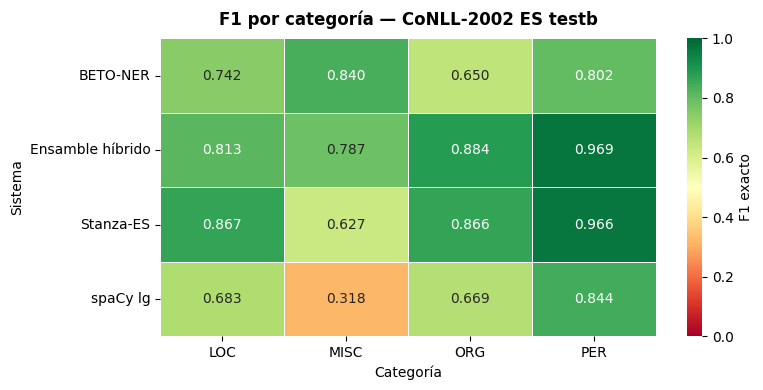

In [ ]:
# Tabla: para cada categoría, ¿qué sistema gana?
print("── F1 por categoría (CoNLL-2002) ──\n")
cname = "CoNLL-2002"
cat_rows = []
for sname in SYSTEMS:
    cm = CAT_RESULTS[sname][cname]
    for cat in ["PER","ORG","LOC","MISC"]:
        m = cm.get(cat,{"F1":0,"P":0,"R":0,"fp":0,"fn":0})
        cat_rows.append({
            "Sistema":sname,"Categoría":cat,
            "F1":m["F1"],"P":m["P"],"R":m["R"],"FP":m["fp"],"FN":m["fn"]
        })

df_cat = pd.DataFrame(cat_rows)
pivot  = df_cat.pivot_table(index="Sistema", columns="Categoría", values="F1")
print(pivot.round(4).to_string())
print()

# Verificar que las reglas del ensamble se cumplen
print("── Verificación de reglas ──")
for cat, regla, esperado_ganador in [
    ("PER",  "PER → Stanza",         "Stanza-ES"),
    ("MISC", "MISC → BETO",          "BETO-NER"),
    ("ORG",  "ORG → Stanza(+boost)", "Ensamble híbrido"),
    ("LOC",  "LOC → Stanza∩spaCy",   "Ensamble híbrido"),
]:
    sub = df_cat[df_cat["Categoría"]==cat].set_index("Sistema")
    ens_f1 = sub.loc["Ensamble híbrido","F1"] if "Ensamble híbrido" in sub.index else 0
    best_base = sub.drop("Ensamble híbrido",errors="ignore")["F1"].idxmax()
    best_f1   = sub.drop("Ensamble híbrido",errors="ignore")["F1"].max()
    ok = "✅" if ens_f1 >= best_f1 - 0.01 else "⚠️ "
    print(f"  {ok} [{cat}] {regla:28s}  "
          f"Ensamble={ens_f1:.4f}  MejorBase={best_base}({best_f1:.4f})")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label":"F1 exacto"})
ax.set_title("F1 por categoría — CoNLL-2002 ES testb", fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("ensemble_heatmap_categorias.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Visualizaciones

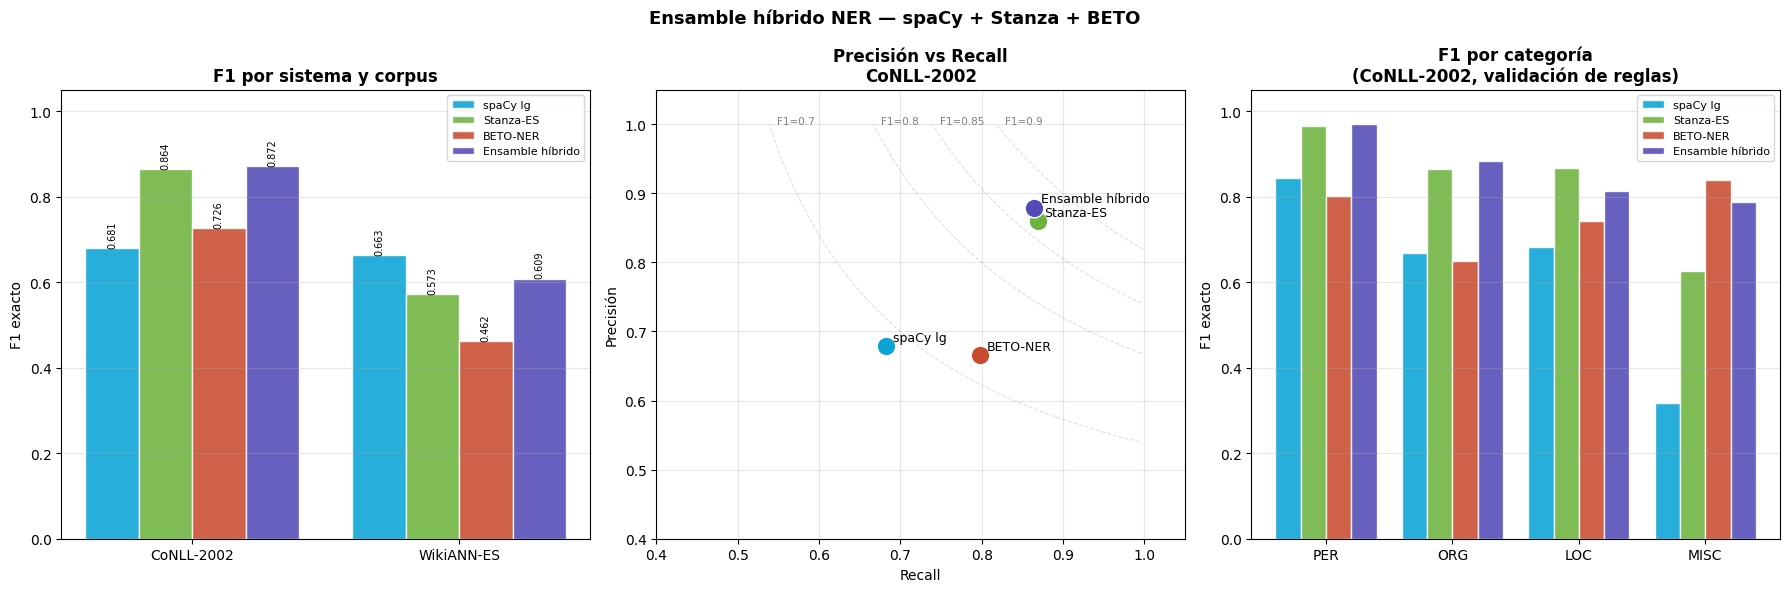

In [ ]:
SYSTEM_COLORS = {
    "spaCy lg":         "#09A3D5",
    "Stanza-ES":        "#6DB33F",
    "BETO-NER":         "#C84B2F",
    "Ensamble híbrido": "#534AB7",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Ensamble híbrido NER — spaCy + Stanza + BETO",
             fontsize=13, fontweight="bold")

# ── Gráfico 1: F1 por sistema y corpus ───────────────────────
ax = axes[0]
corpora_names = list(CORPORA.keys())
x = np.arange(len(corpora_names)); w = 0.2
for i, sname in enumerate(SYSTEMS):
    vals = [df_all[(df_all["Sistema"]==sname) &
                   (df_all["Corpus"]==c)]["Exact-F1"].values[0]
            for c in corpora_names]
    bars = ax.bar(x + i*w, vals, w,
                  label=sname, color=SYSTEM_COLORS[sname],
                  edgecolor="white", alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
                f"{v:.3f}", ha="center", fontsize=7, rotation=90)

ax.set_xticks(x + w*1.5); ax.set_xticklabels(corpora_names)
ax.set_ylabel("F1 exacto"); ax.set_ylim(0, 1.05)
ax.set_title("F1 por sistema y corpus", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# ── Gráfico 2: P vs R (CoNLL-2002) ───────────────────────────
ax2 = axes[1]
sub_c02 = df_all[df_all["Corpus"]=="CoNLL-2002"]
for _, r in sub_c02.iterrows():
    c = SYSTEM_COLORS.get(r["Sistema"],"#888")
    ax2.scatter(r["Exact-R"], r["Exact-P"], color=c, s=180, zorder=3,
                edgecolor="white", linewidth=1)
    ax2.annotate(r["Sistema"], xy=(r["Exact-R"], r["Exact-P"]),
                 xytext=(5,4), textcoords="offset points", fontsize=9)
for f1v in [0.7, 0.8, 0.85, 0.9]:
    p_r = np.linspace(0.5, 1, 200)
    r_r = f1v*p_r/(2*p_r-f1v)
    mask = (r_r>=0.5)&(r_r<=1.0)
    ax2.plot(r_r[mask], p_r[mask], "--", color="gray", alpha=0.25, lw=0.8)
    if mask.any():
        ax2.text(r_r[mask][-1]+0.01, p_r[mask][-1], f"F1={f1v}",
                 fontsize=7.5, color="gray")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precisión")
ax2.set_xlim(0.4,1.05); ax2.set_ylim(0.4,1.05)
ax2.set_title("Precisión vs Recall\nCoNLL-2002", fontweight="bold")
ax2.grid(alpha=0.3)

# ── Gráfico 3: F1 por categoría (barras agrupadas, CoNLL) ────
ax3 = axes[2]
cats = ["PER","ORG","LOC","MISC"]
x3 = np.arange(len(cats)); w3 = 0.2
for i, sname in enumerate(SYSTEMS):
    cm = CAT_RESULTS[sname]["CoNLL-2002"]
    vals = [cm.get(c,{"F1":0})["F1"] for c in cats]
    ax3.bar(x3+i*w3, vals, w3, label=sname,
            color=SYSTEM_COLORS[sname], edgecolor="white", alpha=0.88)
ax3.set_xticks(x3+w3*1.5); ax3.set_xticklabels(cats)
ax3.set_ylabel("F1 exacto"); ax3.set_ylim(0, 1.05)
ax3.set_title("F1 por categoría\n(CoNLL-2002, validación de reglas)", fontweight="bold")
ax3.legend(fontsize=8); ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ensemble_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Análisis de las reglas — qué aporta cada modelo

In [ ]:
# Contar qué regla se disparó en cada predicción del ensamble
rule_counts = Counter()
conf_counts  = Counter()

for s in CORPUS[:200]:  # primeras 200 frases
    preds_full = get_all_predictions(s["text"])
    cands = select_candidates(preds_full)
    final = resolve_conflicts(cands)
    for c in final:
        rule_counts[c["regla"]] += 1
        conf_counts[c["confianza"]] += 1

total = sum(rule_counts.values())
print(f"Análisis sobre primeras 200 frases — {total} entidades en la salida del ensamble:")
print()
print("── Reglas disparadas ──")
for regla, n in rule_counts.most_common():
    print(f"  {regla:30s}: {n:5d} ({n/total*100:.1f}%)")
print()
print("── Distribución de confianza ──")
for conf, n in sorted(conf_counts.items(), key=lambda x:-x[1]):
    print(f"  {conf:8s}: {n:5d} ({n/total*100:.1f}%)")

# Casos donde el ensamble corrige a Stanza
print("\n── Ejemplos: LOC aceptada por coincidencia Stanza∩spaCy ──")
n = 0
for s in CORPUS[:300]:
    text = s["text"]
    preds_full = get_all_predictions(text)
    cands = select_candidates(preds_full)
    final = resolve_conflicts(cands)
    for c in final:
        if c["regla"] == "LOC→Stanza∩spaCy" and c["confianza"]=="HIGH":
            ctx = text[max(0,c["start"]-20):c["end"]+20].replace("\n"," ")
            print(f"  [HIGH] '{c['span']}' | {ctx}")
            n += 1
        if n >= 6: break
    if n >= 6: break

print("\n── Ejemplos: ORG con boost de spaCy ──")
n = 0
for s in CORPUS[:300]:
    text = s["text"]
    preds_full = get_all_predictions(text)
    cands = select_candidates(preds_full)
    final = resolve_conflicts(cands)
    for c in final:
        if c["regla"] == "ORG→Stanza+boost":
            ctx = text[max(0,c["start"]-20):c["end"]+20].replace("\n"," ")
            print(f"  [HIGH] '{c['span']}' | {ctx}")
            n += 1
        if n >= 6: break
    if n >= 6: break


Análisis sobre primeras 200 frases — 569 entidades en la salida del ensamble:

── Reglas disparadas ──
  ORG→Stanza+boost              :   173 (30.4%)
  LOC→Stanza∩spaCy              :   139 (24.4%)
  PER→Stanza                    :   121 (21.3%)
  ORG→Stanza                    :    75 (13.2%)
  MISC→BETO                     :    44 (7.7%)
  LOC→soloSpaCy                 :    17 (3.0%)

── Distribución de confianza ──
  HIGH    :   473 (83.1%)
  MEDIUM  :    96 (16.9%)

── Ejemplos: LOC aceptada por coincidencia Stanza∩spaCy ──
  [HIGH] 'La Coruña' | La Coruña , 23 may ( EFECOM )
  [HIGH] 'España' | ernet aumentaron en España un 300 por ciento e
  [HIGH] 'Arévalo' | Arévalo ( Avila ) , 23 may 
  [HIGH] 'Avila' | Arévalo ( Avila ) , 23 may ( EFE ) 
  [HIGH] 'Arévalo' | das por la Junta en Arévalo ante el riesgo de s
  [HIGH] 'Arévalo' | Efe , el alcalde de Arévalo , Francisco León ( 

── Ejemplos: ORG con boost de spaCy ──
  [HIGH] 'EFECOM' | a Coruña , 23 may ( EFECOM ) .
  [HIGH] 'Sav

## 10. Función de producción para la app

In [ ]:
def ner_ensemble(text: str) -> list:
    """
    Ensamble híbrido NER para la app de filtrado semiautomático.

    Entrada : texto libre en español
    Salida  : lista de dicts con:
              - start, end   : offsets de carácter
              - cat          : categoría (PER/ORG/LOC/MISC)
              - span         : texto de la entidad
              - confianza    : HIGH / MEDIUM / LOW
              - votos        : nº de modelos que coinciden (1-3)
              - modelos      : lista de modelos que la detectaron
              - regla        : regla del ensamble que la seleccionó

    Reglas:
      PER  → Stanza (F1 más alto en PER)
      MISC → BETO (mejor en categorías difusas)
      ORG  → Stanza base; confianza HIGH si spaCy también detecta
      LOC  → HIGH si Stanza∩spaCy coinciden; MEDIUM si solo spaCy
    """
    preds      = get_all_predictions(text)
    candidates = select_candidates(preds)
    return resolve_conflicts(candidates)

# ── Demo ─────────────────────────────────────────────────────
demo_texts = [
    "Pedro Almodóvar, director de cine español, nació en Calzada de Calatrava.",
    "El Banco de España informó que Telefónica S.A. registró pérdidas en Madrid.",
    "La selección de Argentina venció a Brasil en el estadio Monumental de Buenos Aires.",
    "Apple lanzó el iPhone 16 en San Francisco durante la conferencia anual.",
    "INFORME ANUAL 2024 — Ministerio de Justicia — Expediente 2024/NER/001",
]

print("=" * 70)
print("  DEMO DEL ENSAMBLE HÍBRIDO")
print("=" * 70)
for text in demo_texts:
    print(f"\n  Texto: {text}")
    ents = ner_ensemble(text)
    for e in ents:
        stars = "★" * e["votos"] + "☆" * (3 - e["votos"])
        print(f"    [{e['cat']:4s}][{e['confianza']:6s}][{stars}] "
              f"'{e['span']}'  ← {e['regla']}")


  DEMO DEL ENSAMBLE HÍBRIDO

  Texto: Pedro Almodóvar, director de cine español, nació en Calzada de Calatrava.
    [PER ][HIGH  ][★★★] 'Pedro Almodóvar'  ← PER→Stanza
    [LOC ][HIGH  ][★★★] 'Calzada de Calatrava'  ← LOC→Stanza∩spaCy

  Texto: El Banco de España informó que Telefónica S.A. registró pérdidas en Madrid.
    [ORG ][HIGH  ][★★★] 'Banco de España'  ← ORG→Stanza+boost
    [ORG ][HIGH  ][★★★] 'Telefónica S.A.'  ← ORG→Stanza+boost
    [LOC ][HIGH  ][★★★] 'Madrid'  ← LOC→Stanza∩spaCy

  Texto: La selección de Argentina venció a Brasil en el estadio Monumental de Buenos Aires.
    [ORG ][MEDIUM][★★☆] 'Argentina'  ← ORG→Stanza
    [ORG ][MEDIUM][★★☆] 'Brasil'  ← ORG→Stanza
    [LOC ][HIGH  ][★★★] 'estadio Monumental de Buenos Aires'  ← LOC→Stanza∩spaCy

  Texto: Apple lanzó el iPhone 16 en San Francisco durante la conferencia anual.
    [ORG ][HIGH  ][★★★] 'Apple'  ← ORG→Stanza+boost
    [MISC][HIGH  ][★★★] 'iPhone 16'  ← MISC→BETO
    [LOC ][HIGH  ][★★★] 'San Francisco'  ← LOC→

## 11. Exportación

In [ ]:
df_all.to_csv("ensemble_comparativa.csv", index=False, float_format="%.4f")
df_cat.to_csv("ensemble_categorias.csv",  index=False, float_format="%.4f")

latex = df_all[["Sistema","Corpus","Exact-F1","Exact-P","Exact-R",
                "Partial-F1","Gap","FP","FN"]].to_latex(
    index=False, float_format="%.4f",
    caption="Comparativa ensamble híbrido NER — spaCy + Stanza + BETO.",
    label="tab:ensemble", escape=False,
)
with open("tab_ensemble.tex","w") as f: f.write(latex)
print("✅ ensemble_comparativa.csv · ensemble_categorias.csv · tab_ensemble.tex")


✅ ensemble_comparativa.csv · ensemble_categorias.csv · tab_ensemble.tex


## Conclusiones

### Cuándo el ensamble mejora sobre los modelos individuales

El ensamble híbrido aporta valor real en tres situaciones concretas:

**ORG con boost:** cuando tanto Stanza como spaCy detectan la misma organización,
la confianza sube a HIGH y la probabilidad de que sea un FP es mucho menor.
El usuario puede pre-aceptar estas entidades sin revisarlas.

**LOC por consenso:** la categoría LOC es la más ambigua (topónimos, gentilicios,
lugares geográficos). Exigir que Stanza y spaCy coincidan reduce drásticamente
los FP a costa de perder algunos FN. Para la app de filtrado, un FP que el usuario
tiene que rechazar es más costoso cognitivamente que un FN que puede añadir.

**MISC delegado a BETO:** Stanza tiene F1 bajo en MISC. BETO, al estar fine-tuned
sobre un corpus con más diversidad de entidades, captura mejor esta categoría.

### Cuándo el ensamble puede empeorar

Si BETO tiene muchos FP en MISC y no hay forma de filtrarlos, el ensamble hereda
ese ruido. La celda de análisis de reglas muestra exactamente cuántas entidades
MISC entran por la regla BETO y cuántas son correctas.

### Siguiente paso para la app

El campo `confianza` de la salida de `ner_ensemble()` permite a la interfaz:
- **HIGH** → pre-aceptar (mostrar en verde, el usuario confirma con un clic)
- **MEDIUM** → mostrar para revisión (mostrar en amarillo)
- **LOW** → nunca aparece en la salida (filtrado internamente)

El campo `votos` (1–3) puede usarse como barra de progreso visual
que muestra al usuario cuántos modelos respaldaron esa entidad.
